## 1. Imports

All required libraries are imported here. `pandas`/`numpy` for data handling, `matplotlib`/`seaborn` for visualisation, and `scikit-learn` for models and preprocessing.

In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline


## 2. Data Loading & Overview

The UCI Auto MPG dataset is loaded and preprocessed: `mpg` is converted to km/g, missing horsepower values are median-imputed, and the categorical `origin` column is one-hot encoded.

In [2]:
def read_csv_file(file_path):
    try:
        return pd.read_csv(file_path)
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return None


def preprocessing(df):
    df["km_per_gallon"] = df["mpg"] * 1.60934
    df["horsepower"] = df["horsepower"].replace("?", np.nan).astype(float)
    df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())
    df = df.rename(columns={"model year": "model_year"})
    df = df.drop(columns=["car name", "mpg"])
    df = pd.get_dummies(df, columns=["origin"], dtype=int)
    return df


df = read_csv_file("auto-mpg.csv")
if df is None:
    raise RuntimeError("Failed to load dataset.")
df = preprocessing(df)
print("Dataset loaded and preprocessed.")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")


Dataset loaded and preprocessed.
Shape: (398, 10)
Columns: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'km_per_gallon', 'origin_1', 'origin_2', 'origin_3']


## 3. Exploratory Data Analysis

Explore dataset shape, missing values, target distribution, feature outliers, and inter-feature correlations before building any models.

In [3]:
print("=== Dataset Shape ===")
print(df.shape)

print("\n=== Statistical Summary ===")
print(df.describe())

print("\n=== Missing Values ===")
print(df.isnull().sum())


=== Dataset Shape ===
(398, 10)

=== Statistical Summary ===
        cylinders  displacement  horsepower       weight  acceleration  \
count  398.000000    398.000000  398.000000   398.000000    398.000000   
mean     5.454774    193.425879  104.304020  2970.424623     15.568090   
std      1.701004    104.269838   38.222625   846.841774      2.757689   
min      3.000000     68.000000   46.000000  1613.000000      8.000000   
25%      4.000000    104.250000   76.000000  2223.750000     13.825000   
50%      4.000000    148.500000   93.500000  2803.500000     15.500000   
75%      8.000000    262.000000  125.000000  3608.000000     17.175000   
max      8.000000    455.000000  230.000000  5140.000000     24.800000   

       model_year  km_per_gallon    origin_1    origin_2    origin_3  
count  398.000000     398.000000  398.000000  398.000000  398.000000  
mean    76.010050      37.842943    0.625628    0.175879    0.198492  
std      3.697627      12.578576    0.484569    0.381197   

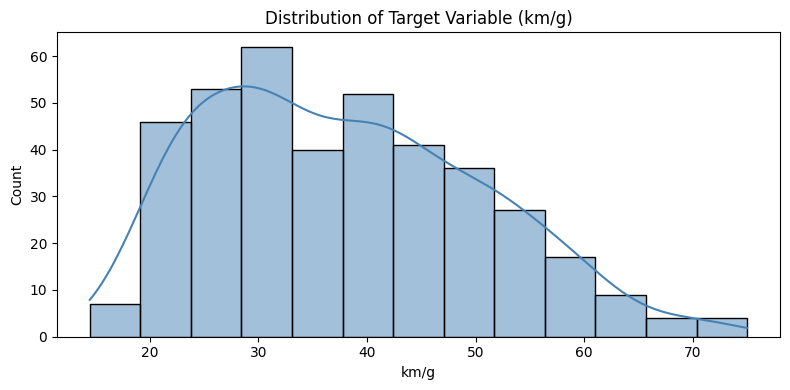

Saved: target_distribution.png


In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df["km_per_gallon"], kde=True, color="steelblue")
plt.title("Distribution of Target Variable (km/g)")
plt.xlabel("km/g")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: target_distribution.png")


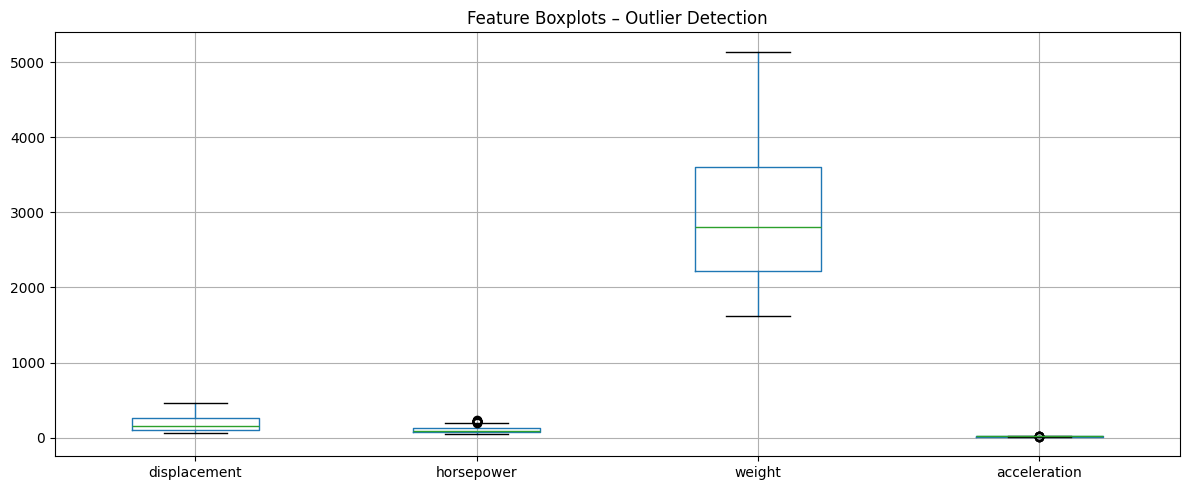

Saved: boxplot_outliers.png


In [5]:
df[["displacement", "horsepower", "weight", "acceleration"]].boxplot(figsize=(12, 5))
plt.title("Feature Boxplots – Outlier Detection")
plt.tight_layout()
plt.savefig("boxplot_outliers.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: boxplot_outliers.png")


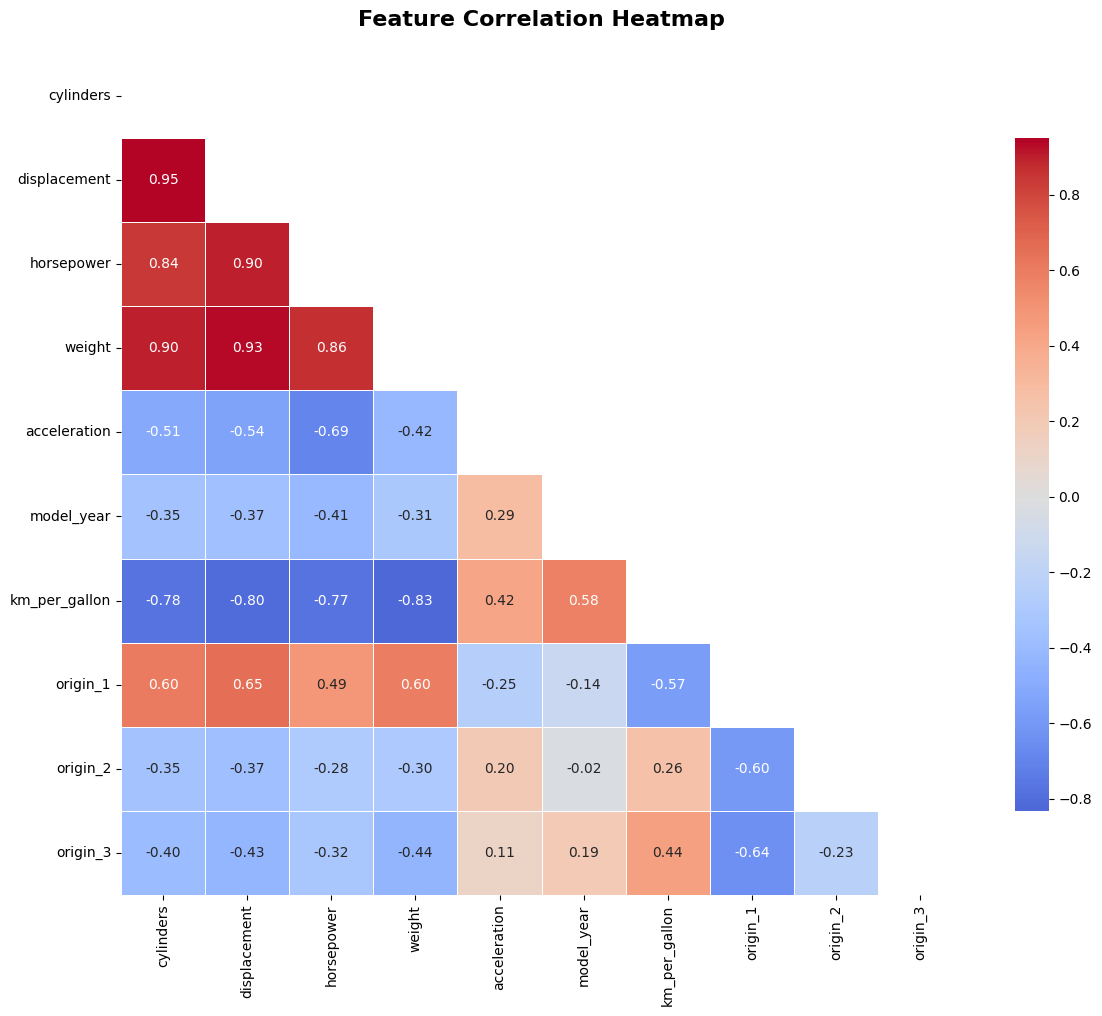

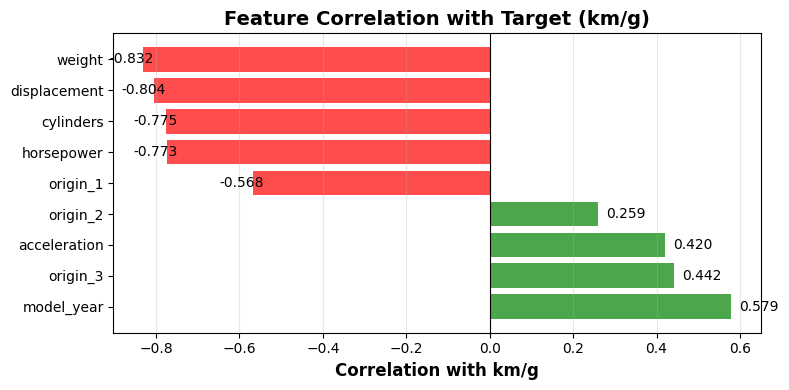

Saved: correlation_heatmap.png, correlation_with_target.png


In [6]:
# ── Correlation Heatmap ──────────────────────────────────────────────────────
plt.figure(figsize=(12, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Heatmap", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

# ── Correlation with Target ───────────────────────────────────────────────────
target_corr = corr["km_per_gallon"].drop("km_per_gallon").sort_values(ascending=False)
colors = ["green" if v > 0 else "red" for v in target_corr.values]
plt.figure(figsize=(8, 4))
plt.barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.7)
plt.yticks(range(len(target_corr)), target_corr.index)
plt.xlabel("Correlation with km/g", fontsize=12, fontweight="bold")
plt.title("Feature Correlation with Target (km/g)", fontsize=14, fontweight="bold")
plt.axvline(x=0, color="black", linewidth=0.8)
plt.grid(axis="x", alpha=0.3)
for i, v in enumerate(target_corr.values):
    plt.text(v + (0.02 if v > 0 else -0.08), i, f"{v:.3f}", va="center", fontsize=10)
plt.tight_layout()
plt.savefig("correlation_with_target.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: correlation_heatmap.png, correlation_with_target.png")


/var/folders/l1/9f4yxnh50fxgm1nx91tm_1600000gn/T/ipykernel_14699/348478072.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_bp, labels=cyls, patch_artist=True)


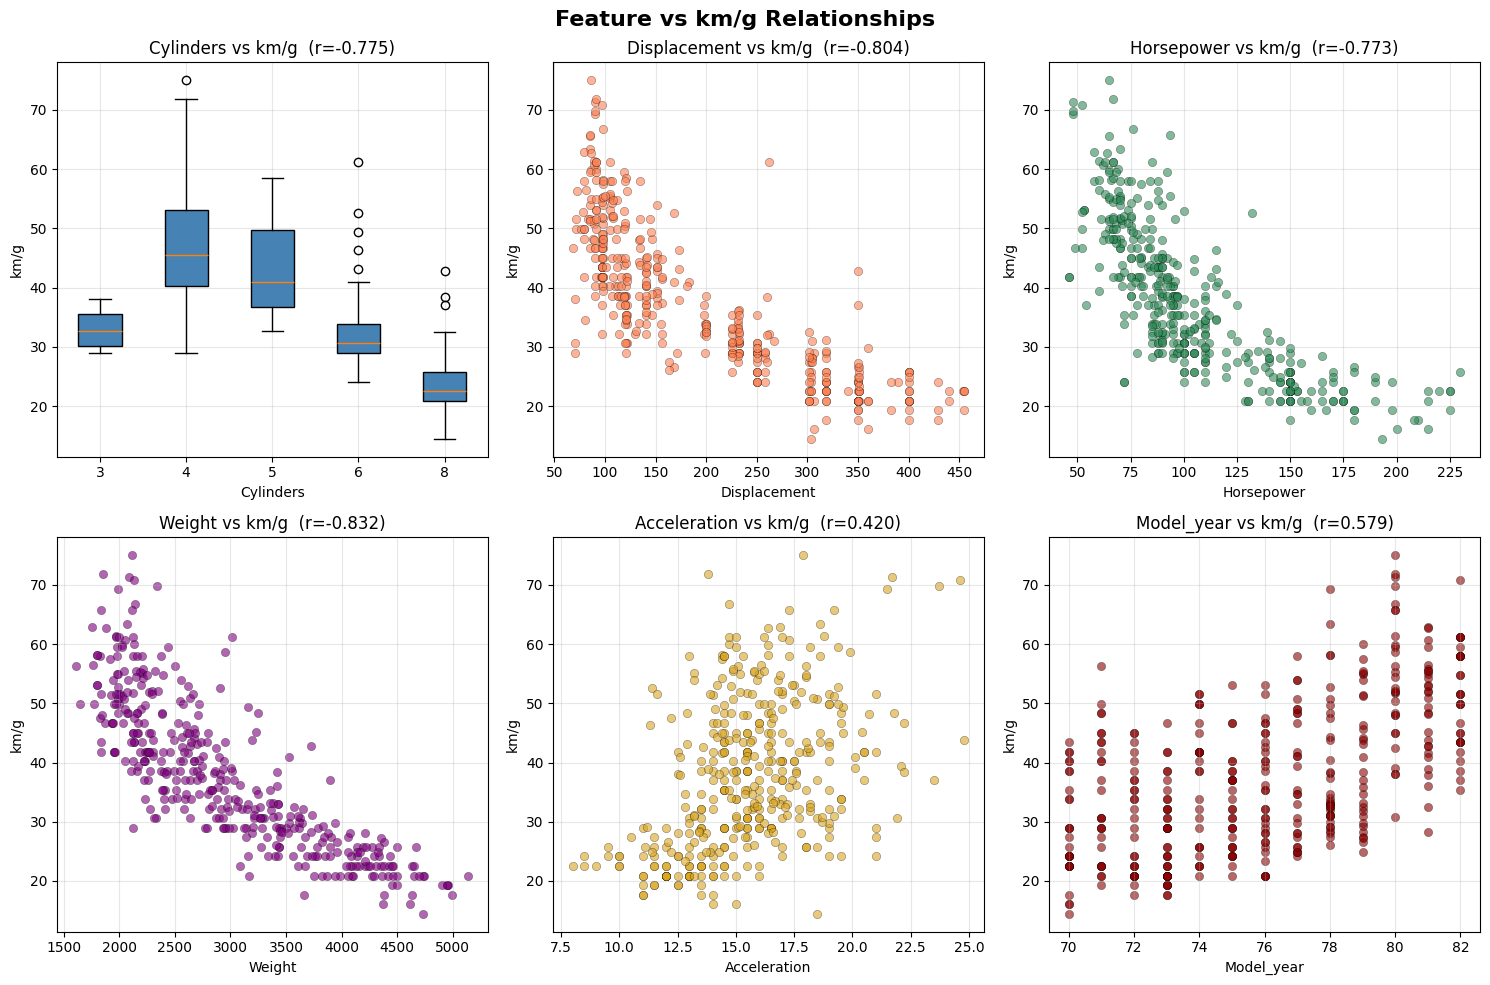

Saved: scatter_relationships.png


In [7]:
numeric_cols = ["cylinders", "displacement", "horsepower", "weight", "acceleration", "model_year"]
available = [c for c in numeric_cols if c in df.columns]
n_cols = min(3, len(available))
n_rows = (len(available) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
fig.suptitle("Feature vs km/g Relationships", fontsize=16, fontweight="bold")
axes = np.array(axes).flatten()
palette = ["steelblue", "coral", "seagreen", "purple", "goldenrod", "darkred"]

for idx, feat in enumerate(available):
    ax = axes[idx]
    corr_val = df[feat].corr(df["km_per_gallon"])
    if feat == "cylinders":
        cyls = sorted(df["cylinders"].unique())
        data_bp = [df[df["cylinders"] == c]["km_per_gallon"] for c in cyls]
        bp = ax.boxplot(data_bp, labels=cyls, patch_artist=True)
        for box in bp["boxes"]:
            box.set_facecolor(palette[idx % len(palette)])
    else:
        ax.scatter(df[feat], df["km_per_gallon"], alpha=0.6,
                   c=palette[idx % len(palette)], edgecolors="black", linewidths=0.3)
    ax.set_xlabel(feat.capitalize())
    ax.set_ylabel("km/g")
    ax.set_title(f"{feat.capitalize()} vs km/g  (r={corr_val:.3f})")
    ax.grid(True, alpha=0.3)

for idx in range(len(available), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig("scatter_relationships.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: scatter_relationships.png")


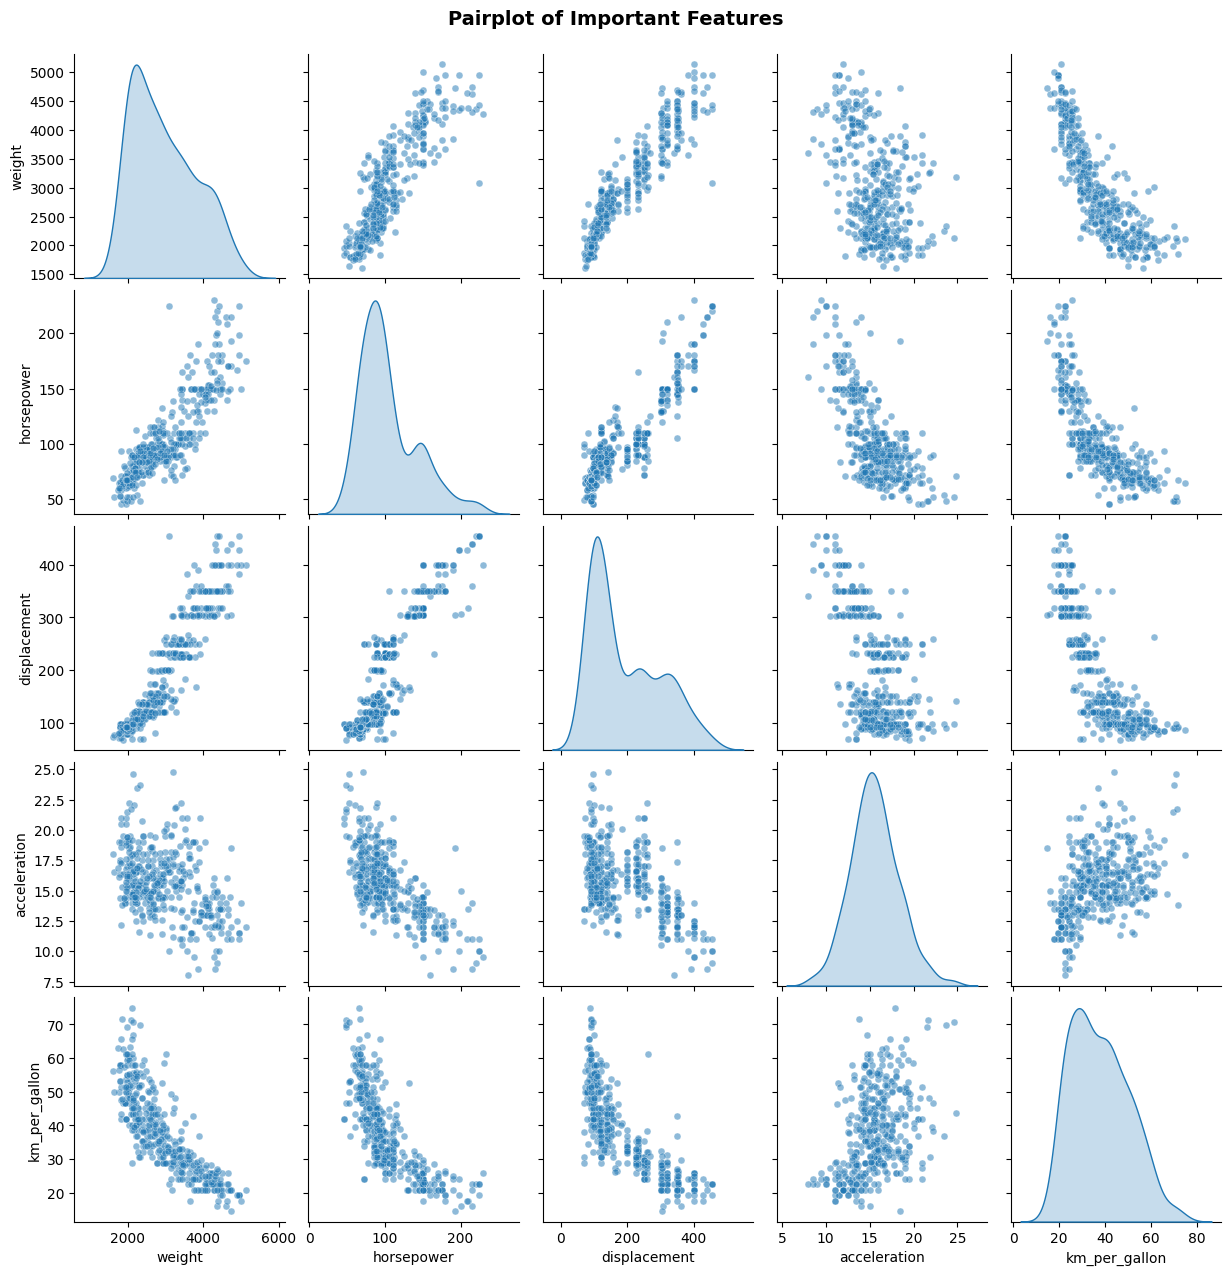

Saved: pairplot_features.png


In [8]:
important = ["weight", "horsepower", "displacement", "acceleration", "km_per_gallon"]
available_pair = [f for f in important if f in df.columns]
pp = sns.pairplot(df[available_pair], diag_kind="kde", plot_kws={"alpha": 0.5, "s": 25})
pp.fig.suptitle("Pairplot of Important Features", y=1.02, fontsize=14, fontweight="bold")
plt.savefig("pairplot_features.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: pairplot_features.png")


## 4. Preprocessing Pipeline

Features (X) and target (y) are separated from the preprocessed DataFrame. Scaling is deliberately deferred until *after* the train-test split to prevent data leakage.

In [9]:
def get_feature_and_target(df):
    """Return unscaled X and y — scaling happens after the split."""
    x = df.drop(columns=["km_per_gallon"])
    y = df["km_per_gallon"]
    return x, y


x, y = get_feature_and_target(df)
print(f"Features shape : {x.shape}")
print(f"Target shape   : {y.shape}")
print(f"Feature columns: {list(x.columns)}")


Features shape : (398, 9)
Target shape   : (398,)
Feature columns: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_1', 'origin_2', 'origin_3']


## 5. Train-Test Split

The dataset is split 80/20 *before* any scaling occurs. The `StandardScaler` is then fit exclusively on the training set (`fit_transform`) and only applied to the test set (`transform`), so no test-set information leaks into the scaler parameters.

In [10]:
def train_test_split_data(x, y, test_size=0.2, random_state=42):
    return train_test_split(x, y, test_size=test_size, random_state=random_state)


x_train, x_test, y_train, y_test = train_test_split_data(x, y)

# Fit scaler on training data ONLY — prevents data leakage
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled  = scaler.transform(x_test)

pickle.dump(scaler, open("scaler.pkl", "wb"))

print(f"Train : {x_train_scaled.shape[0]} samples")
print(f"Test  : {x_test_scaled.shape[0]} samples")
print("scaler.pkl saved (fitted on training data only).")


Train : 318 samples
Test  : 80 samples
scaler.pkl saved (fitted on training data only).


## 6. Model Training

Two models are trained on the scaled training set: Linear Regression as an interpretable baseline, and Random Forest Regressor as the primary model. Both are serialised to disk.

In [11]:
def train_model_lr(x_train, y_train):
    lr = LinearRegression()
    lr.fit(x_train, y_train)
    pickle.dump(lr, open("model_lr.pkl", "wb"))
    return lr


def train_model_rf(x_train, y_train):
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(x_train, y_train)
    pickle.dump(rf, open("model_rf.pkl", "wb"))
    return rf


lr_model = train_model_lr(x_train_scaled, y_train)
rf_model = train_model_rf(x_train_scaled, y_train)
print("Linear Regression and Random Forest trained and saved.")


Linear Regression and Random Forest trained and saved.


## 7. Evaluation – Hold-out Set

Models are evaluated on the held-out test set using MAE, RMSE, and R². A naive mean-predictor baseline is included to quantify how much the models improve over simply guessing the training mean for every sample.

In [12]:
def evaluate(model, x_test, y_test):
    y_pred = model.predict(x_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"\nModel : {model.__class__.__name__}")
    print(f"  MAE  : {mae:.4f} km/g")
    print(f"  RMSE : {rmse:.4f} km/g")
    print(f"  R²   : {r2:.4f}")
    return mae, rmse, r2


print("=" * 55)
print("HOLD-OUT TEST SET EVALUATION  (80/20 split)")
print("=" * 55)
lr_mae_ho, lr_rmse_ho, lr_r2_ho = evaluate(lr_model, x_test_scaled, y_test)
rf_mae_ho, rf_rmse_ho, rf_r2_ho = evaluate(rf_model, x_test_scaled, y_test)

# Naive baseline – predict training-set mean for every test sample
baseline_pred  = np.full(len(y_test), y_train.mean())
baseline_mae   = mean_absolute_error(y_test, baseline_pred)
baseline_rmse  = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_r2    = r2_score(y_test, baseline_pred)

print(f"\nNaive Baseline (predict mean = {y_train.mean():.2f} km/g for all samples):")
print(f"  MAE  : {baseline_mae:.4f} km/g")
print(f"  RMSE : {baseline_rmse:.4f} km/g")
print(f"  R²   : {baseline_r2:.4f}")


HOLD-OUT TEST SET EVALUATION  (80/20 split)

Model : LinearRegression
  MAE  : 3.6824 km/g
  RMSE : 4.6472 km/g
  R²   : 0.8449

Model : RandomForestRegressor
  MAE  : 2.5384 km/g
  RMSE : 3.4471 km/g
  R²   : 0.9147

Naive Baseline (predict mean = 37.99 km/g for all samples):
  MAE  : 9.5843 km/g
  RMSE : 11.8244 km/g
  R²   : -0.0040


## 8. K-Fold Cross Validation

5-Fold cross-validation is run on the scaled training set to obtain a more robust performance estimate and to compare model stability across different data partitions.


K-FOLD CROSS VALIDATION  (k=5)


/var/folders/l1/9f4yxnh50fxgm1nx91tm_1600000gn/T/ipykernel_14699/3398114401.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([lr_res[key], rf_res[key]],
/var/folders/l1/9f4yxnh50fxgm1nx91tm_1600000gn/T/ipykernel_14699/3398114401.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([lr_res[key], rf_res[key]],
/var/folders/l1/9f4yxnh50fxgm1nx91tm_1600000gn/T/ipykernel_14699/3398114401.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([lr_res[key], rf_res[key]],


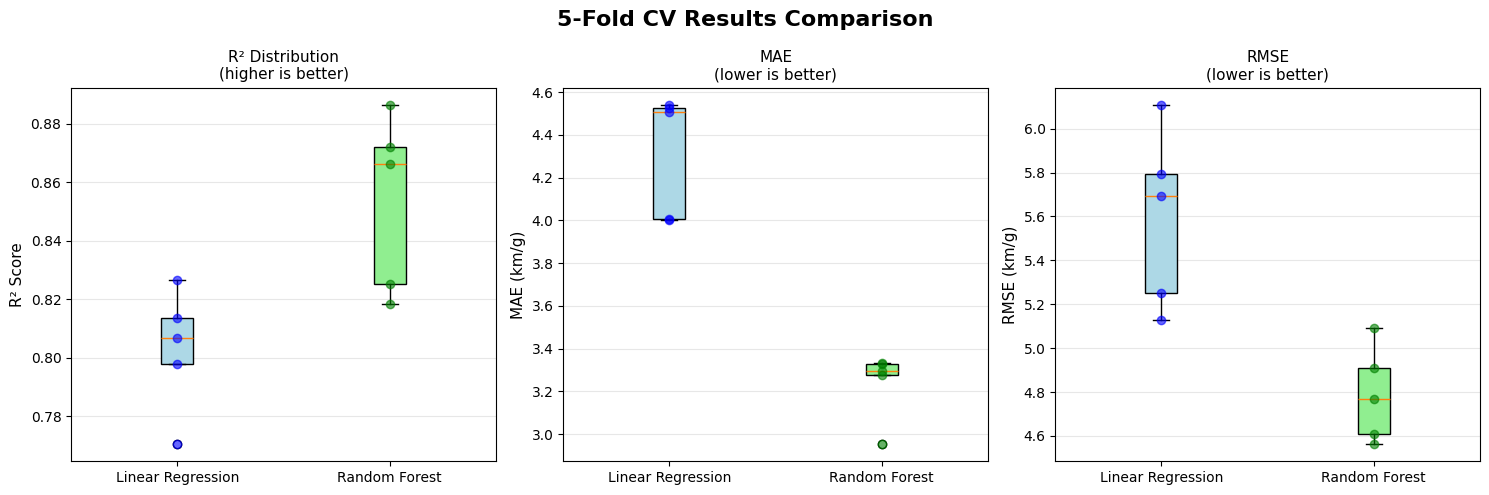

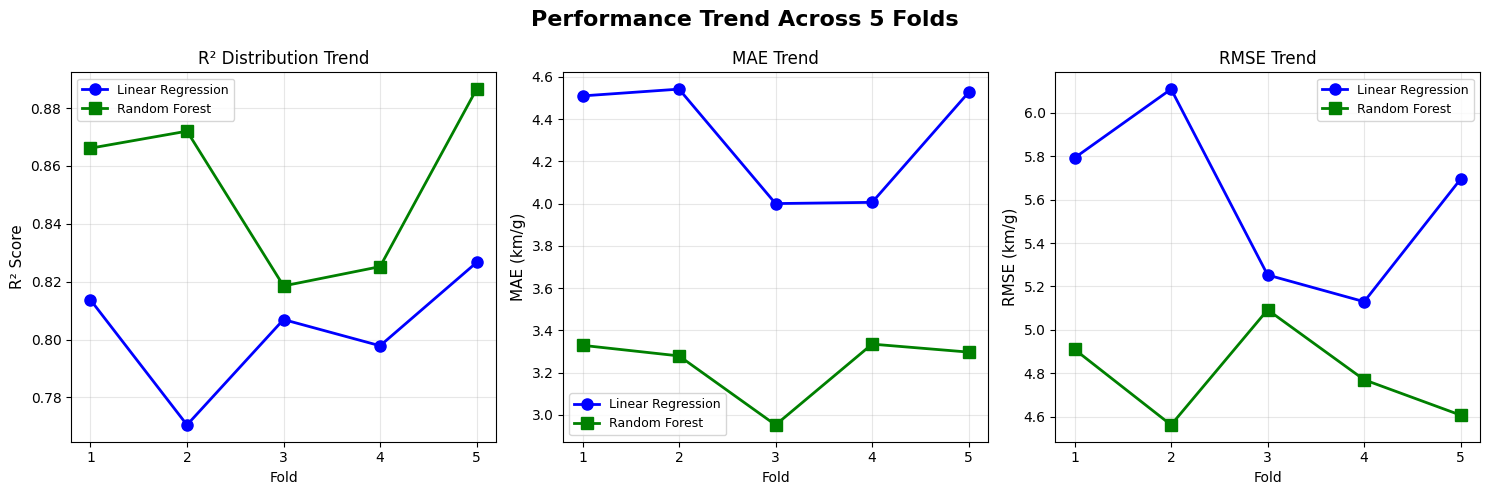

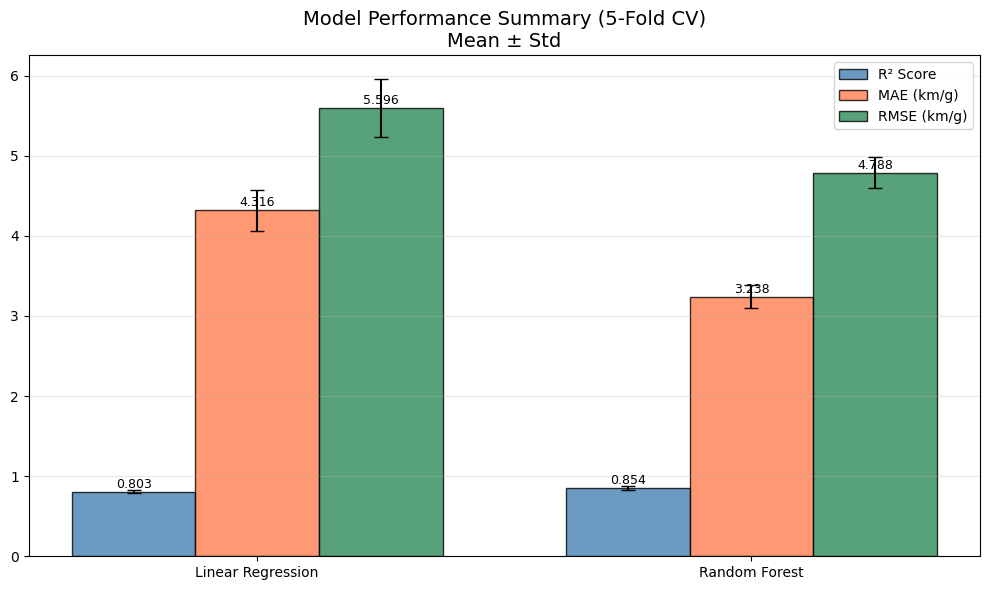


SUMMARY – 5-FOLD CROSS VALIDATION
Metric                    Linear Regression              Random Forest
----------------------------------------------------------------------
R² (Mean±Std)             0.8031 ± 0.0188            0.8537 ± 0.0269
MAE (Mean±Std)            4.3165 ± 0.2565            3.2381 ± 0.1445
RMSE (Mean±Std)           5.5956 ± 0.3596            4.7883 ± 0.1958


In [13]:
def cross_validate_model_detailed(model, x, y, cv=5):
    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
    r2_scores   = cross_val_score(model, x, y, cv=kfold, scoring="r2")
    mae_scores  = -cross_val_score(model, x, y, cv=kfold, scoring="neg_mean_absolute_error")
    rmse_scores = np.sqrt(-cross_val_score(model, x, y, cv=kfold, scoring="neg_mean_squared_error"))
    return {
        "r2_scores": r2_scores, "mae_scores": mae_scores, "rmse_scores": rmse_scores,
        "r2_mean":   r2_scores.mean(),   "r2_std":   r2_scores.std(),
        "mae_mean":  mae_scores.mean(),  "mae_std":  mae_scores.std(),
        "rmse_mean": rmse_scores.mean(), "rmse_std": rmse_scores.std(),
    }


def plot_kfold_results(x, y, cv=5):
    print("\n" + "=" * 60)
    print(f"K-FOLD CROSS VALIDATION  (k={cv})")
    print("=" * 60)

    lr = LinearRegression()
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    lr_res = cross_validate_model_detailed(lr, x, y, cv)
    rf_res = cross_validate_model_detailed(rf, x, y, cv)
    folds  = range(1, cv + 1)

    metrics = [
        ("r2_scores",   "R² Score",   "R² Distribution\n(higher is better)"),
        ("mae_scores",  "MAE (km/g)", "MAE\n(lower is better)"),
        ("rmse_scores", "RMSE (km/g)","RMSE\n(lower is better)"),
    ]

    # Figure 1 – Boxplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"{cv}-Fold CV Results Comparison", fontsize=16, fontweight="bold")
    for ax, (key, ylabel, title) in zip(axes, metrics):
        bp = ax.boxplot([lr_res[key], rf_res[key]],
                        labels=["Linear Regression", "Random Forest"], patch_artist=True)
        bp["boxes"][0].set_facecolor("lightblue")
        bp["boxes"][1].set_facecolor("lightgreen")
        ax.scatter([1] * cv, lr_res[key], color="blue",  alpha=0.6, zorder=3)
        ax.scatter([2] * cv, rf_res[key], color="green", alpha=0.6, zorder=3)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=11)
        ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("kfold_boxplots_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Figure 2 – Trend across folds
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f"Performance Trend Across {cv} Folds", fontsize=16, fontweight="bold")
    for ax, (key, ylabel, title) in zip(axes, metrics):
        ax.plot(folds, lr_res[key], "bo-", label="Linear Regression", linewidth=2, markersize=8)
        ax.plot(folds, rf_res[key], "gs-", label="Random Forest",     linewidth=2, markersize=8)
        ax.set_xlabel("Fold")
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title.split("\n")[0] + " Trend")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(list(folds))
    plt.tight_layout()
    plt.savefig("kfold_trend_across_folds.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Figure 3 – Summary bar chart
    fig, ax = plt.subplots(figsize=(10, 6))
    x_pos = np.arange(2)
    width = 0.25
    for i, (mk, sk, label, color) in enumerate([
        ("r2_mean",   "r2_std",   "R² Score",   "steelblue"),
        ("mae_mean",  "mae_std",  "MAE (km/g)", "coral"),
        ("rmse_mean", "rmse_std", "RMSE (km/g)","seagreen"),
    ]):
        means = [lr_res[mk], rf_res[mk]]
        stds  = [lr_res[sk], rf_res[sk]]
        bars  = ax.bar(x_pos + (i - 1) * width, means, width, label=label,
                       yerr=stds, capsize=5, color=color, alpha=0.8, edgecolor="black")
        for bar in bars:
            h = bar.get_height()
            ax.annotate(f"{h:.3f}", xy=(bar.get_x() + bar.get_width() / 2, h),
                        xytext=(0, 3), textcoords="offset points", ha="center", fontsize=9)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(["Linear Regression", "Random Forest"])
    ax.set_title(f"Model Performance Summary ({cv}-Fold CV)\nMean ± Std", fontsize=14)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("kfold_summary_bar_chart.png", dpi=300, bbox_inches="tight")
    plt.show()

    # Print summary table
    print(f"\n{'='*70}")
    print(f"SUMMARY – {cv}-FOLD CROSS VALIDATION")
    print(f"{'='*70}")
    print(f"{'Metric':<25} {'Linear Regression':<30} {'Random Forest'}")
    print(f"{'-'*70}")
    for label, mk, sk in [("R² (Mean±Std)", "r2_mean","r2_std"),
                           ("MAE (Mean±Std)","mae_mean","mae_std"),
                           ("RMSE (Mean±Std)","rmse_mean","rmse_std")]:
        print(f"{label:<25} {lr_res[mk]:.4f} ± {lr_res[sk]:.4f}"
              f"{'':>12}{rf_res[mk]:.4f} ± {rf_res[sk]:.4f}")
    print(f"{'='*70}")

    return lr_res, rf_res


lr_cv_results, rf_cv_results = plot_kfold_results(x_train_scaled, y_train, cv=5)


In [14]:
lr_mae_cv_mean = lr_cv_results["mae_mean"]
rf_mae_cv_mean = rf_cv_results["mae_mean"]
improvement = ((lr_mae_cv_mean - rf_mae_cv_mean) / lr_mae_cv_mean) * 100
print(f"MAE improvement (RF vs LR): {improvement:.1f}%")


MAE improvement (RF vs LR): 25.0%


## 9. Diagnostic Plots

A Predicted vs Actual scatter and a Residual plot verify that the Random Forest's errors are random and well-calibrated. The dashed diagonal (y = x) and horizontal zero line represent perfect prediction.

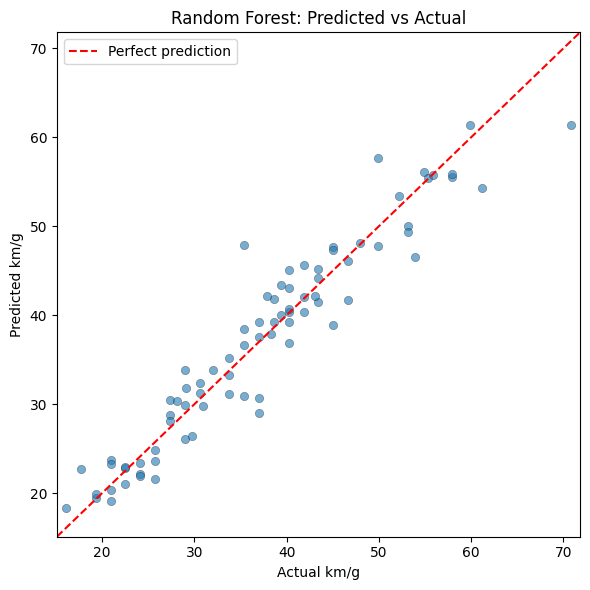

Saved: predicted_vs_actual.png


In [15]:
def plot_predicted_vs_actual(y_test, y_pred):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.6, edgecolors="black", linewidths=0.3)
    lims = [min(y_test.min(), y_pred.min()) - 1, max(y_test.max(), y_pred.max()) + 1]
    plt.plot(lims, lims, "r--", label="Perfect prediction")
    plt.xlim(lims); plt.ylim(lims)
    plt.xlabel("Actual km/g")
    plt.ylabel("Predicted km/g")
    plt.title("Random Forest: Predicted vs Actual")
    plt.legend()
    plt.tight_layout()
    plt.savefig("predicted_vs_actual.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: predicted_vs_actual.png")


y_pred_rf = rf_model.predict(x_test_scaled)
plot_predicted_vs_actual(y_test, y_pred_rf)


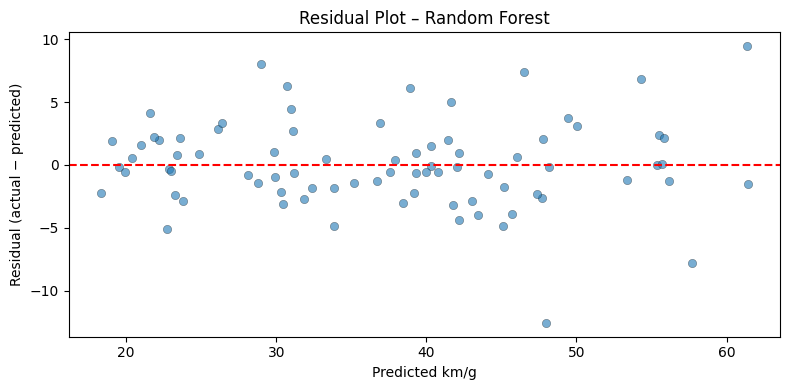

Saved: residuals.png


In [16]:
def plot_residuals(y_test, y_pred):
    residuals = y_test - y_pred
    plt.figure(figsize=(8, 4))
    plt.scatter(y_pred, residuals, alpha=0.6, edgecolors="black", linewidths=0.3)
    plt.axhline(0, color="red", linestyle="--")
    plt.xlabel("Predicted km/g")
    plt.ylabel("Residual (actual − predicted)")
    plt.title("Residual Plot – Random Forest")
    plt.tight_layout()
    plt.savefig("residuals.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved: residuals.png")


plot_residuals(y_test, y_pred_rf)


## 10. Save Models

All serialised artefacts are confirmed present. Feature importance from the trained Random Forest is plotted to show which inputs drove predictions most strongly.

model_lr.pkl: saved
model_rf.pkl: saved
scaler.pkl: saved


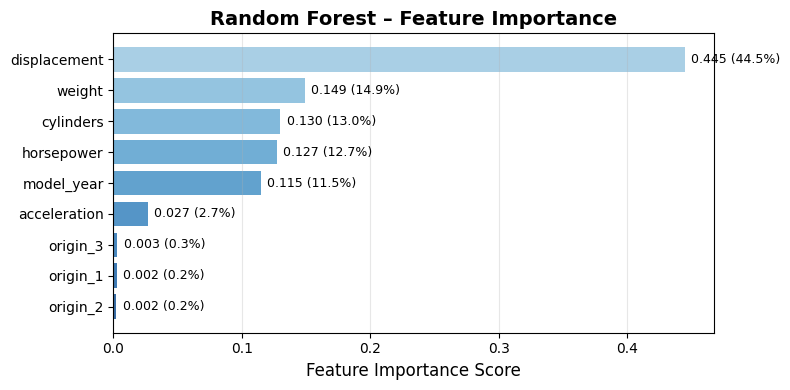

Saved: feature_importance_rf.png


In [17]:
import os

for fname in ["model_lr.pkl", "model_rf.pkl", "scaler.pkl"]:
    status = "saved" if os.path.exists(fname) else "MISSING"
    print(f"{fname}: {status}")

# Feature importance
feature_names = list(x.columns)
importances   = rf_model.feature_importances_
indices       = np.argsort(importances)[::-1]

plt.figure(figsize=(8, 4))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(importances)))
bars   = plt.barh(range(len(importances)), importances[indices], color=colors, alpha=0.8)
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel("Feature Importance Score", fontsize=12)
plt.title("Random Forest – Feature Importance", fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
for i, idx in enumerate(indices):
    w = importances[idx]
    plt.text(w + 0.005, i, f"{w:.3f} ({w*100:.1f}%)", va="center", fontsize=9)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance_rf.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: feature_importance_rf.png")


In [18]:
print("\n" + "=" * 60)
print("FINAL METRICS SUMMARY")
print("=" * 60)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("-" * 60)
print(f"{'Naive Baseline':<25} {baseline_mae:>8.4f} {baseline_rmse:>8.4f} {baseline_r2:>8.4f}")
print(f"{'Linear Regression':<25} {lr_mae_ho:>8.4f} {lr_rmse_ho:>8.4f} {lr_r2_ho:>8.4f}")
print(f"{'Random Forest':<25} {rf_mae_ho:>8.4f} {rf_rmse_ho:>8.4f} {rf_r2_ho:>8.4f}")
print("=" * 60)
print(f"\n5-Fold CV (training set):")
print(f"{'Model':<25} {'MAE (mean)':>12} {'RMSE (mean)':>12} {'R² (mean)':>12}")
print("-" * 60)
print(f"{'Linear Regression':<25} {lr_cv_results['mae_mean']:>12.4f} {lr_cv_results['rmse_mean']:>12.4f} {lr_cv_results['r2_mean']:>12.4f}")
print(f"{'Random Forest':<25} {rf_cv_results['mae_mean']:>12.4f} {rf_cv_results['rmse_mean']:>12.4f} {rf_cv_results['r2_mean']:>12.4f}")
print("=" * 60)
print(f"\nMAE improvement (RF vs LR, 5-fold CV): {improvement:.1f}%")



FINAL METRICS SUMMARY
Model                          MAE     RMSE       R²
------------------------------------------------------------
Naive Baseline              9.5843  11.8244  -0.0040
Linear Regression           3.6824   4.6472   0.8449
Random Forest               2.5384   3.4471   0.9147

5-Fold CV (training set):
Model                       MAE (mean)  RMSE (mean)    R² (mean)
------------------------------------------------------------
Linear Regression               4.3165       5.5956       0.8031
Random Forest                   3.2381       4.7883       0.8537

MAE improvement (RF vs LR, 5-fold CV): 25.0%
